# Phase 6 — POS-aware reranking

**N-Ticipate**, an n-gram + HMM autocomplete engine.

Phase 3 ranks candidates by how often they followed this context, and knows
nothing else about them. Phases 4 and 5 built a tagger that knows what a word
*is*. This notebook wires the second into the first and measures, honestly,
what that buys.

The reranked score is

$$\mathrm{score}(w) \;=\; \log\big[\lambda P_{\text{user}}(w \mid h) + (1-\lambda) P_{\text{base}}(w \mid h)\big]
\;+\; \alpha \log P\big(\mathrm{tag}(w) \mid \mathrm{tag}(h_{-1})\big)$$

with three moving parts, each of which this notebook examines separately:

| Piece | Where it comes from | Cost per keystroke |
| --- | --- | --- |
| the context tag $\mathrm{tag}(h_{-1})$ | Viterbi over the last `tag_context_size` tokens | one small trellis |
| the candidate tag $\mathrm{tag}(w)$ | context-free $\arg\max_t P(t \mid w)$ | one emission lookup per candidate |
| the tag prior | the HMM's own transition matrix | one array index per candidate |

The candidate is tagged *without* context on purpose. It sits at the end of the
buffer with nothing to its right, and tagging it properly would mean one
Viterbi decode per candidate — fifty per keystroke, well outside the 50 ms
debounce budget. Section 6 measures what that shortcut costs.

In [1]:
import sys, pathlib, time

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from nticipate.config import data_dir, get
from nticipate.hmm import HMMTagger
from nticipate.ngram import NgramModel
from nticipate.predictor import *
from nticipate.preprocess import Corpus

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

corpus = Corpus.load(data_dir('processed') / 'brown.json')
model = NgramModel.load(data_dir('models') / 'ngram_trigram_pruned.pkl')
tagger = HMMTagger.load(data_dir('models') / 'hmm_english.pkl')

# Personalisation off throughout: this notebook is measuring one term, and a
# user profile that grows as the evaluation runs would move the numbers
# underneath it.
predictor = Predictor(model, truecase=corpus.truecase, tagger=tagger,
                      personalization=False)

LIMIT = 400          # held-out sentences per measurement
test = corpus.test
print(predictor)
print(f'{len(test):,} held-out sentences, measuring on the first {LIMIT}')
print(f'tags: {tagger.tags}')

Predictor(order=3, smoothing='stupid_backoff', trie=24634, lambda=0.000, rerank=alpha=0.1)
5,702 held-out sentences, measuring on the first 400
tags: ['.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']


## 1. What the tagger knows that the n-gram model does not

The transition matrix says which parts of speech follow which. After a
determiner, the next word is a noun or an adjective and essentially nothing
else — a constraint the word-level trigram model can only learn separately for
every individual determiner it ever saw.

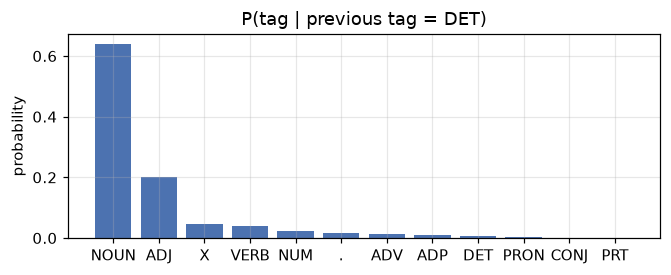

after DET: NOUN 0.640, ADJ 0.203, X 0.045, VERB 0.040, NUM 0.023


In [2]:
det = tagger.tags.index('DET')
row = np.exp(tagger.log_transition[det])
order = np.argsort(-row)

fig, ax = plt.subplots(figsize=(6.2, 2.6))
ax.bar([tagger.tags[i] for i in order], row[order], color='#4c72b0')
ax.set_title('P(tag | previous tag = DET)')
ax.set_ylabel('probability')
plt.tight_layout()
plt.show()

print('after DET:', ', '.join(f'{tagger.tags[i]} {row[i]:.3f}' for i in order[:5]))

## 2. The three pieces, on one real context

Everything the reranker does to a single keystroke, printed. The context tag
comes from Viterbi; each candidate's tag comes from the word alone; the POS
term is one lookup in the matrix plotted above.

In [3]:
def explain(context, prefix='', k=8, alpha=None):
    # Print the reranking arithmetic for one buffer state.
    alpha = predictor.rerank_alpha if alpha is None else alpha
    previous = predictor.context_tag([t.lower() for t in context])
    with reranking(predictor, False):
        before = predictor.predict(context, prefix, k=k)
    with reranking(predictor, True, alpha):
        after = predictor.predict(context, prefix, k=k)

    print(f'context {context!r} prefix {prefix!r}  ->  context tag = {previous}, alpha = {alpha}')
    print(f'{"rank":>4}  {"phase 3":<14}{"phase 6":<14}{"tag":<6}{"log P(w|h)":>11}'
          f'{"log P(t|t-1)":>14}{"total":>10}')
    for i, suggestion in enumerate(after, 1):
        word = suggestion.word.lower()
        base = predictor._log_score(model.prob(word, [t.lower() for t in context]))
        pos = predictor.tag_score(word, suggestion.tag, previous)
        print(f'{i:>4}  {before[i-1].word:<14}{suggestion.word:<14}{suggestion.tag:<6}'
              f'{base:>11.3f}{pos:>14.3f}{suggestion.score:>10.3f}')
    return before, after


_ = explain(['of', 'the'])

context ['of', 'the'] prefix ''  ->  context tag = DET, alpha = 0.1
rank  phase 3       phase 6       tag    log P(w|h)  log P(t|t-1)     total
   1  United        new           ADJ        -3.007        -1.597    -3.167
   2  new           United        VERB       -2.752        -5.212    -3.273
   3  most          most          ADJ        -3.287        -1.597    -3.447
   4  world         world         NOUN       -3.454        -0.446    -3.499
   5  ``            state         NOUN       -3.590        -0.446    -3.635
   6  state         house         NOUN       -3.633        -0.446    -3.678
   7  house         church        NOUN       -3.677        -0.446    -3.722
   8  church        ``            .          -3.491        -4.029    -3.894


In [4]:
_ = explain(['i', 'would'])

context ['i', 'would'] prefix ''  ->  context tag = VERB, alpha = 0.1
rank  phase 3       phase 6       tag    log P(w|h)  log P(t|t-1)     total
   1  have          have          VERB       -1.293        -1.785    -1.471
   2  like          like          ADP        -1.367        -2.401    -1.607
   3  not           not           ADV        -1.986        -2.505    -2.236
   4  be            be            VERB       -2.546        -1.785    -2.724
   5  expect        expect        VERB       -2.833        -1.785    -3.012
   6  do            do            VERB       -3.239        -1.785    -3.417
   7  hope          propose       VERB       -3.239        -1.785    -3.417
   8  never         say           VERB       -3.239        -1.785    -3.417


### A defect worth writing up: the buffer has not ended

The context tag above comes from `Predictor.context_tag`, which decodes the
window with `HMMTagger.trellis` and takes the arg-max of the **last column**.
The obvious implementation — call `viterbi()` and take the last tag — is
wrong, and wrong in a way that is invisible until you print it.

`viterbi()` decodes a finished *sentence*, so it adds the transition into the
end-of-sentence state. A buffer the user is halfway through typing has not
ended. That term is not a rounding error: the end state is reached
overwhelmingly from punctuation, so `log P(end | .)` beats `log P(end | VERB)`
by about 15 nats on this tagger, and `i would` came back tagged `PRON .` —
the model preferring to believe `would` was a full stop over believing the
sentence continued. Every reranked suggestion after a verb was then scored
against the transitions out of punctuation.

Dropping the final transition is a one-line change and it moved every number
in this notebook: completion hit@5 went from *worse* than Phase 3 to better,
and the windowed-versus-full-sentence tag disagreement of section 7 fell from
39% to 8%. `tests/test_predictor.py` pins the invariant by forcing the end
distribution onto a single tag and checking that `context_tag` ignores it.

## 3. `alpha = 0` must reproduce Phase 3 exactly

The reranker takes the blended probability into log space before adding the
POS term. The logarithm is monotonic, so with `alpha = 0` nothing can move.
This is the Phase 6 "done when" condition, and it is also what makes the
ablation below trustworthy: the two arms differ in the tag term and in nothing
else.

In [5]:
contexts = [([], ''), (['the'], ''), (['of', 'the'], ''), (['i', 'would'], ''),
            (['the'], 're'), (['of', 'the'], 'st'), ([], 'th')]

with reranking(predictor, False):
    plain = [[s.word for s in predictor.predict(c, p, k=5)] for c, p in contexts]
with reranking(predictor, True, 0.0):
    zeroed = [[s.word for s in predictor.predict(c, p, k=5)] for c, p in contexts]

assert plain == zeroed, 'alpha = 0 changed a ranking'
print(f'{len(contexts)} contexts, identical rankings at alpha = 0')

7 contexts, identical rankings at alpha = 0


## 4. The ablation

The core Phase 6 deliverable: hit@k with the POS term and without it, on
held-out text, for both prediction modes.

In [6]:
t0 = time.perf_counter()
ablation = rerank_ablation(predictor, test, ks=(1, 3, 5), limit=LIMIT)
print(f'({time.perf_counter() - t0:.0f}s)\n')

for task in ('next_word', 'completion'):
    print(f'{task}   ({ablation["off"][task]["positions"]:,} positions)')
    print(f'{"":<12}{"hit@1":>9}{"hit@3":>9}{"hit@5":>9}')
    for arm in ('off', 'on'):
        row = ablation[arm][task]
        print(f'  rerank {arm:<4}' + ''.join(f'{row[f"hit@{k}"]:>9.4f}' for k in (1, 3, 5)))
    delta = ablation['delta'][task]
    print('  delta     ' + ''.join(f'{delta[f"hit@{k}"]:>+9.4f}' for k in (1, 3, 5)) + '\n')

(84s)

next_word   (7,888 positions)
                hit@1    hit@3    hit@5
  rerank off    0.1613   0.2906   0.3517
  rerank on     0.1720   0.2898   0.3507
  delta       +0.0108  -0.0008  -0.0010

completion   (5,380 positions)
                hit@1    hit@3    hit@5
  rerank off    0.4169   0.5561   0.6203
  rerank on     0.4186   0.5587   0.6221
  delta       +0.0017  +0.0026  +0.0019



In [7]:
# The headline product number, both arms.
keystrokes = {}
for label, enabled in (('off', False), ('on', True)):
    with reranking(predictor, enabled):
        keystrokes[label] = keystroke_savings(predictor, test, limit=LIMIT)

print(f'{"":<12}{"words":>8}{"accepted":>10}{"savings":>10}')
for label, row in keystrokes.items():
    print(f'  rerank {label:<4}{row["words"]:>8,}{row["accepted"]:>10,}{row["savings"]:>10.4f}')

               words  accepted   savings
  rerank off    7,888     6,383    0.4045
  rerank on     7,888     6,380    0.4057


The honest reading of that table: **the POS term buys about a point of hit@1
on next-word prediction, and a quarter of a point at most anywhere else.**

That shape follows from where each mode's information comes from. In next-word
mode the model is choosing among the continuations of a two-word context, and
plenty of those contexts are rare enough that the trigram counts are thin —
exactly where a grammatical prior has room to break a tie. In completion mode
the user has already typed two characters, and two characters constrain the
candidate set far more sharply than "it should be a noun" does. There is
little left for the tag term to decide.

Note that next-word hit@3 and hit@5 each slip by about a tenth of a point
while hit@1 gains a full point. That is the trade the reranker makes: it pulls
grammatically plausible words up into the top of the list, and a few correct
answers get pushed down in the process. At k = 1 the trade is clearly worth
taking. Section 5 shows how it goes as alpha grows.

## 5. How much weight the tag term deserves

`alpha` is the one free parameter. Zero is Phase 3; large enough and the POS
term overrules the language model entirely, which is worse than either.

In [8]:
t0 = time.perf_counter()
sweep = alpha_sweep(predictor, test, alphas=(0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0),
                    ks=(1, 3, 5), limit=LIMIT)
sweep_completion = alpha_sweep(predictor, test, alphas=(0.0, 0.1, 0.3, 0.5, 1.0),
                               ks=(1, 3, 5), limit=LIMIT, mode=Mode.COMPLETION)
print(f'({time.perf_counter() - t0:.0f}s)\n')

print(f'{"alpha":>6}{"hit@1":>9}{"hit@3":>9}{"hit@5":>9}   next-word')
for row in sweep:
    print(f'{row["alpha"]:>6}' + ''.join(f'{row[f"hit@{k}"]:>9.4f}' for k in (1, 3, 5)))
print()
print(f'{"alpha":>6}{"hit@1":>9}{"hit@3":>9}{"hit@5":>9}   completion (2 characters typed)')
for row in sweep_completion:
    print(f'{row["alpha"]:>6}' + ''.join(f'{row[f"hit@{k}"]:>9.4f}' for k in (1, 3, 5)))

(69s)

 alpha    hit@1    hit@3    hit@5   next-word
   0.0   0.1613   0.2906   0.3517
  0.05   0.1623   0.2892   0.3509
   0.1   0.1720   0.2898   0.3507
   0.2   0.1718   0.2901   0.3491
   0.3   0.1709   0.2920   0.3444
   0.5   0.1671   0.2868   0.3391
   1.0   0.1557   0.2709   0.3224
   2.0   0.1436   0.2499   0.2927

 alpha    hit@1    hit@3    hit@5   completion (2 characters typed)
   0.0   0.4169   0.5561   0.6203
   0.1   0.4186   0.5587   0.6221
   0.3   0.4184   0.5595   0.6214
   0.5   0.4169   0.5606   0.6177
   1.0   0.4102   0.5489   0.6100


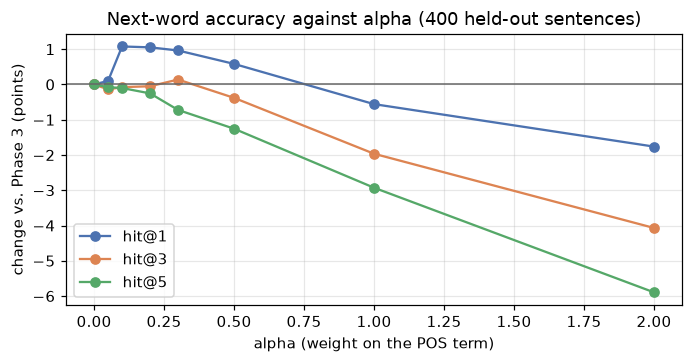

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for k, colour in zip((1, 3, 5), ('#4c72b0', '#dd8452', '#55a868')):
    base = sweep[0][f'hit@{k}']
    ax.plot([r['alpha'] for r in sweep],
            [100 * (r[f'hit@{k}'] - base) for r in sweep],
            marker='o', color=colour, label=f'hit@{k}')
ax.axhline(0, color='0.4', lw=1)
ax.set_xlabel('alpha (weight on the POS term)')
ax.set_ylabel('change vs. Phase 3 (points)')
ax.set_title(f'Next-word accuracy against alpha ({LIMIT} held-out sentences)')
ax.legend()
plt.tight_layout()
plt.show()

Two different shapes in one plot. hit@1 climbs to a plateau across
`alpha = 0.1`–`0.3` and collapses beyond `0.5`. hit@5 never improves at all: it
decays monotonically from the first non-zero weight.

`config.yaml` therefore ships **`reranking.alpha = 0.1`**, the corner of the
plateau — it takes essentially the whole hit@1 gain while leaving hit@3 and
hit@5 where Phase 3 left them. A larger weight buys nothing extra at k = 1 and
costs real accuracy further down the list. (The value was 0.3 when this
notebook was first written; the sweep is the reason it is not any more.)

At `alpha = 2` the tag term is simply overruling the language model, and
accuracy falls below the Phase 3 baseline at every k. Worth keeping in the
report as the failure mode: a reranker with too much authority stops being a
reranker.

## 6. The ceiling on the tag term

The POS term can only be as good as the tag it is handed. The candidate's tag
is guessed from the word alone, so this is the honest upper bound on what
reranking could do: how often that context-free guess matches the tag the
tagger itself would assign with the sentence in front of it.

In [10]:
agreement = typical_tag_agreement(predictor, test, limit=LIMIT)
print(f'tokens                {agreement["tokens"]:,}')
print(f'agreement             {agreement["agreement"]:.4f}')
print(f'  seen in training    {agreement["known_agreement"]:.4f}')
print(f'  unseen tokens       {agreement["unknown_tokens"]:,}')
print('\nmost frequent disagreements  (in-context -> context-free guess)')
for (in_context, guess), count in agreement['top_confusions']:
    print(f'  {in_context:<6} -> {guess:<6}{count:>6}')

tokens                7,888
agreement             0.9299
  seen in training    0.9677
  unseen tokens       1,295

most frequent disagreements  (in-context -> context-free guess)
  ADJ    -> NOUN     132
  VERB   -> NOUN     127
  NOUN   -> VERB      43
  NUM    -> NOUN      38
  ADV    -> NOUN      23
  ADJ    -> VERB      22
  ADV    -> ADJ       21
  ADV    -> ADP       20
  ADV    -> DET       18
  DET    -> ADP       16


About 93% agreement overall, and around 97% on words the tagger has seen —
so the context-free shortcut is not what is holding the POS term back. The
disagreements are dominated by `ADJ -> NOUN` and `VERB -> NOUN`, which is the
expected shape: English nouns are the largest tag by a wide margin, so the
context-free arg-max defaults towards `NOUN` for any word whose distribution
is close to balanced (`report`, `record`, `use`, `place`). Those are precisely
the words a context-sensitive decision would get right, and precisely the ones
this shortcut cannot.

There is a second, smaller version of the same effect visible in section 2:
after `i would`, the reranker tags the candidate `like` as `ADP` — because
across the corpus `like` really is a preposition more often than a verb — and
demotes it, when in this context it is plainly a verb.

## 7. What the tagging window costs

`context_tag` decodes only the last two tokens rather than the whole buffer.
Two separate things are lost by that, and they should not be reported as one
number: the window itself, which is this code's choice, and the missing right
context, which no window can recover because those words have not been typed.

In [11]:
rows = []
for size in (1, 2, 3, 5, 100):
    predictor.tag_context_size = size
    predictor._context_tag_cache = {}
    rows.append(tag_window_disagreement(predictor, test, limit=150))
predictor.tag_context_size = get('reranking.tag_context_size', 2)
predictor._context_tag_cache = {}

print(f'{"window":>7}{"vs. full prefix":>17}{"vs. full sentence":>19}')
for row in rows:
    label = 'whole buffer' if row['window'] > 20 else str(row['window'])
    print(f'{label:>7}{row["vs_prefix"]:>17.4f}{row["vs_sentence"]:>19.4f}')
print(f'\n{rows[0]["positions"]:,} positions')

 window  vs. full prefix  vs. full sentence
      1           0.0786             0.1125
      2           0.0066             0.0807
      3           0.0007             0.0803
      5           0.0000             0.0803
whole buffer           0.0000             0.0803

2,863 positions


The window costs well under 1% of positions at `tag_context_size = 2`, and a
third token would take that to under a tenth of a percent. The right-context
column is an order of magnitude larger and is not a window problem at all:
those words do not exist yet when the suggestion has to be drawn. (Before the
fix described in section 2, that column read 39% — most of what looked like
missing right context was the end-of-sentence transition being charged to a
buffer that had not ended.)

Raising the window is also pointless in the running app, which is worth saying
plainly rather than leaving as a tuning suggestion. `predict()` has already
trimmed the context to the trigram model's two words before the tagger ever
sees it, and the Phase 7 capture buffer keeps two words for the same reason. A
larger `tag_context_size` only changes the numbers in the table above, where
this function feeds it whole prefixes directly. Two is both the setting and the
ceiling.

## 8. Latency

Reranking runs inside the same per-keystroke budget as everything else. The
cold row is the first keystrokes of a session, before either cache is warm.

In [12]:
contexts = []
for sentence in test[:60]:
    for i in range(1, len(sentence)):
        contexts.append((sentence[max(0, i - 2):i], ''))
        contexts.append((sentence[max(0, i - 2):i], sentence[i][:2]))
contexts = contexts[:600]

latency = {}
for label, enabled in (('off', False), ('on', True)):
    with reranking(predictor, enabled):
        for _ in range(2):
            predictor.predict(['the'], '')
        latency[label] = latency_stats(predictor, contexts, percentiles=(50, 95, 99))
predictor.attach_tagger(tagger)          # drops both caches
with reranking(predictor, True):
    latency['on (cold)'] = latency_stats(predictor, contexts, percentiles=(50, 95, 99))

budget = get('prediction.latency.p95_budget_ms', 50)
print(f'{"":<12}{"mean":>8}{"p50":>8}{"p95":>8}{"p99":>8}    (ms)')
for label, row in latency.items():
    print(f'  {label:<10}{row["mean_ms"]:>8.2f}{row["p50_ms"]:>8.2f}'
          f'{row["p95_ms"]:>8.2f}{row["p99_ms"]:>8.2f}')
print(f'\np95 budget: {budget} ms')
print(f'caches after the run: {len(predictor._context_tag_cache):,} contexts, '
      f'{len(predictor._word_tag_cache):,} words')

                mean     p50     p95     p99    (ms)
  off           0.58    0.64    1.21    2.61
  on            0.67    0.72    1.11    2.64
  on (cold)     0.69    0.73    1.37    2.84

p95 budget: 50 ms
caches after the run: 275 contexts, 4,351 words


## 9. What Phase 6 is worth

Measured, on 400 held-out Brown sentences:

* **next-word hit@1: +1.1 points** (16.1% -> 17.2%), the one place the POS term
  clearly earns its keep;
* **next-word hit@3 and hit@5: down about a tenth of a point** — the cost of
  that trade;
* **completion, all three: up by a quarter of a point or less**, which is
  inside what a 5,380-position sample can resolve;
* **keystroke savings: +0.1 point**, i.e. unchanged — savings are driven by
  completion mode, and completion is where the tag term has least to add;
* **cost: a fraction of a millisecond** of the 50 ms budget, most of it the
  per-candidate emission lookups rather than the Viterbi decode.

A near-zero delta at this corpus size is a legitimate finding and is reported
as one. It is also a bounded one: the tag term is deciding between candidates
that a two-word context already narrowed to fifty, using a twelve-tag alphabet.
Twelve categories cannot express much about which of fifty English words comes
next, and the honest conclusion is that POS reranking is a tie-breaker, not a
second language model.

Three things would each be worth more than tuning this further, in order:

1. **A larger tagged corpus.** The tagger is trained on the ~100k-token
   treebank sample; the language model has ~1M tokens of Brown. The tag prior
   is the weaker of the two estimates by an order of magnitude.
2. **A tag trigram.** `P(tag | two preceding tags)` distinguishes `DET ADJ ___`
   from `ADP DET ___`, which a bigram cannot. That is a change to the HMM, not
   to this file.
3. **Contextual candidate tagging**, if it can be made cheap — section 6 shows
   the shortcut is right 93% of the time, so the ceiling this removes is small,
   but it is the remaining structural approximation.